<a href="https://colab.research.google.com/github/ankit-rathi/quantvesting_v3/blob/main/notebooks/06_QUANTVESTING_SIP_MULTI_STRATEGY_BACKTEST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantvesting — Multi-Strategy SIP Backtest

## 60-month, ₹2.5 lakh/month experiment across allocation styles

This notebook is the next iteration of `06_QUANTVESTING_SIP_BACKTEST.ipynb`. It keeps the same SIP schedule, universe and market-data approach, but turns the test into a **multi-strategy experiment**.

### Common rules for the primary comparison

Every strategy receives exactly the same **₹2.5 lakh on the first available trading day of every month** over the same 60-month window. There is **no starting lump sum**.

For the primary equity strategies:

- maximum **5% of current total corpus per scrip**;
- **no forced selling / no rebalancing** after purchase;
- transaction cost = 10 bps;
- slippage = 5 bps;
- only information available before the purchase is used;
- uninvested cash is carried forward;
- the monthly SIP is allocated only to the strategy's eligible stocks;
- when a stock is already at/above the 5% cap, it receives no new money until room is created by portfolio growth/dilution;
- **X-LC is preferred over H-LC** when the strategy has to rank otherwise comparable candidates.

The goal is not to declare a universal winner from one historical path. The notebook measures how the allocation rules behave across different market regimes, drawdowns, concentration levels and deployment rates.

### Strategies tested

**Primary no-sell strategies:**

1. **Universe Equal-Weight (5%)** — equal monthly target across the whole universe; X-LC is used as priority when the 5% cap prevents a perfectly equal deployment.
2. **ATH Drawdown Top-20 (5%)** — select the 20 stocks furthest below their running ATH; within that pool, X-LC is preferred, then larger ATH drawdown.
3. **200-DMA Drawdown Top-20 (5%)** — select the 20 stocks furthest below their 200-DMA; X-LC is preferred, then larger DMA discount.
4. **ATH + 200-DMA Composite Top-20 (5%)** — combine normalized ATH drawdown and 200-DMA discount into one score.
5. **ATH Drawdown + Recovery Top-20 (5%)** — only stocks meaningfully below ATH but trading at/above their 200-DMA qualify; this is a “buy weakness after confirmation” experiment.
6. **Momentum Top-20 (5%)** — select the strongest medium-term performers using 12-month momentum excluding the most recent month.

**Reference strategies:**

7. **Original Quantvesting Strategy SIP** — retained as a reference only, using the original conviction/ATH-gap entry and frozen-ATH exit mechanics, but with the new 5% cap.
8. **Nifty 50 SIP** — index SIP reference; the 5% single-scrip rule is not applied to the index instrument itself.

### Important interpretation

Distance from ATH or distance below the 200-DMA is **not the same thing as fundamental undervaluation**. Those signals are being tested as price-based allocation rules, not labeled as true value measures.

The notebook also avoids look-ahead bias: a stock's ranking for a monthly SIP is based on the prior available EOD information, and the purchase occurs at the next available open.


In [1]:
# 1. Setup
import sys, subprocess, importlib.util, warnings, math
from pathlib import Path

if importlib.util.find_spec("yfinance") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

DATA_DIR = Path("sample_data")
SIGNAL_FILE = DATA_DIR / "signals.csv"

# Same period and SIP size as the latest notebook.
START_DATE = "2016-10-01"
END_DATE = "2026-10-01"
SIP_AMOUNT = 250_000
SIP_MONTHS = 60

# Common portfolio rules for the new apple-to-apple comparison.
MAX_POSITION_PCT = 0.05
TOP_N = 20
TRANSACTION_COST_BPS = 10
SLIPPAGE_BPS = 5

# Original Quantvesting reference settings.
ENTRY_ATH_GAP = 0.20
MAX_HOLDINGS = 35

# Signal lookbacks.
DMA_WINDOW = 200
MOM_LONG = 252
MOM_SKIP = 21
RECOVERY_ATH_MIN_GAP = 0.20

print("✓ Environment ready")
print(f"✓ SIP: ₹{SIP_AMOUNT:,.0f}/month × {SIP_MONTHS} months = ₹{SIP_AMOUNT*SIP_MONTHS/1e7:.2f} Cr")
print(f"✓ Common max position: {MAX_POSITION_PCT:.0%}")


✓ Environment ready
✓ SIP: ₹250,000/month × 60 months = ₹1.50 Cr
✓ Common max position: 5%


In [2]:
# 2. Load and validate the same signal universe used by the latest notebook
if not SIGNAL_FILE.exists():
    raise FileNotFoundError(f"Missing {SIGNAL_FILE}. Place the same signals.csv beside this notebook.")

signals_config = pd.read_csv(SIGNAL_FILE)
signals_config.columns = [str(c).strip().lower() for c in signals_config.columns]
required = {"symbol", "conviction"}
missing = required - set(signals_config.columns)
if missing:
    raise ValueError(f"signals.csv is missing columns: {sorted(missing)}")

signals_config["symbol"] = signals_config["symbol"].astype(str).str.strip().str.upper()
signals_config["conviction"] = signals_config["conviction"].astype(str).str.strip().str.upper()
allowed = {"X-LC", "H-LC"}
bad = sorted(set(signals_config["conviction"]) - allowed)
if bad:
    raise ValueError(f"Unsupported conviction values: {bad}. Use X-LC or H-LC.")
if signals_config["symbol"].duplicated().any():
    dupes = signals_config.loc[signals_config["symbol"].duplicated(), "symbol"].tolist()
    raise ValueError(f"Duplicate symbols in signals.csv: {dupes}")

# Preserve the exclusion used by the latest notebook.
signals_config = signals_config[signals_config["symbol"] != "LTIM"].reset_index(drop=True)
YF_TICKERS = {f"{s}.NS": s for s in signals_config["symbol"]}

print(f"✓ Signal universe: {len(signals_config)} securities")
display(signals_config.style.hide(axis="index"))


✓ Signal universe: 52 securities


symbol,conviction
BSE,X-LC
BAJAJ-AUTO,X-LC
HDFCAMC,X-LC
M&M,X-LC
HEROMOTOCO,H-LC
BHARTIARTL,H-LC
SIEMENS,H-LC
BOSCHLTD,X-LC
ADANIPORTS,X-LC
TORNTPHARM,H-LC


## 1. Data and SIP schedule

The same monthly contribution is used for every strategy. The first available trading day of each calendar month is the contribution date.

**60 × ₹2.5 lakh = ₹1.50 crore total contributed capital.**

The market-data download starts slightly before the backtest so that the first investment decision can use prior EOD information. No future monthly return is used to choose a stock.


In [3]:
# 3. Download daily market data
# A pre-window is needed for prior-EOD indicators and the first valid 200-DMA values.
data_start = (pd.Timestamp(START_DATE) - pd.Timedelta(days=430)).strftime("%Y-%m-%d")
market_download_end = (pd.Timestamp(END_DATE) + pd.Timedelta(days=2)).strftime("%Y-%m-%d")

def yf_download(tickers, start, end):
    return yf.download(
        tickers,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=False,
        actions=False,
        progress=False,
        repair=True,
        group_by="column",
    )

raw = yf_download(list(YF_TICKERS.keys()), data_start, market_download_end)

# Convert yfinance output to a long table.
rows=[]
if isinstance(raw.columns, pd.MultiIndex):
    fields = set(raw.columns.get_level_values(0))
    for field in ["Open","High","Low","Close"]:
        if field not in fields: continue
        block = raw[field]
        if isinstance(block, pd.Series): block = block.to_frame()
        for ticker in block.columns:
            symbol = YF_TICKERS.get(str(ticker), str(ticker).replace(".NS", ""))
            s = pd.to_numeric(block[ticker], errors="coerce")
            for d,v in s.dropna().items():
                rows.append((pd.Timestamp(d).tz_localize(None), symbol, field, float(v)))
else:
    # Single-ticker fallback.
    ticker = list(YF_TICKERS.keys())[0]
    symbol = YF_TICKERS[ticker]
    for field in ["Open","High","Low","Close"]:
        if field in raw.columns:
            s = pd.to_numeric(raw[field], errors="coerce")
            for d,v in s.dropna().items():
                rows.append((pd.Timestamp(d).tz_localize(None), symbol, field, float(v)))

long = pd.DataFrame(rows, columns=["date","symbol","field","value"])
if long.empty:
    raise RuntimeError("No market data was downloaded. Check internet access and the symbols in signals.csv.")

prices = long.pivot_table(index=["date","symbol"], columns="field", values="value", aggfunc="last").reset_index()
for c in ["Open","High","Low","Close"]:
    if c not in prices.columns:
        raise RuntimeError(f"Downloaded data is missing {c}.")

prices = prices.sort_values(["symbol","date"]).reset_index(drop=True)
prices = prices[(prices["date"] >= pd.Timestamp(data_start)) & (prices["date"] <= pd.Timestamp(END_DATE))].copy()

quality = prices.groupby("symbol").agg(first_date=("date","min"), last_date=("date","max"), rows=("date","size"))
print(f"✓ Downloaded {len(prices):,} daily rows across {prices['symbol'].nunique()} securities")
print(f"✓ Data window: {prices['date'].min():%d %b %Y} → {prices['date'].max():%d %b %Y}")
display(quality.sort_values("rows").head(15).style.format({"first_date":"{:%d %b %Y}","last_date":"{:%d %b %Y}","rows":"{:,.0f}"}))


✓ Downloaded 133,459 daily rows across 52 securities
✓ Data window: 29 Jul 2015 → 18 Sep 2026


,first_date,last_date,rows
symbol,,,
HYUNDAI,22 Oct 2024,18 Sep 2026,478
JIOFIN,21 Aug 2023,18 Sep 2026,765
LICI,17 May 2022,18 Sep 2026,"1,079"
POLYCAB,16 Apr 2019,18 Sep 2026,"1,840"
HDFCAMC,06 Aug 2018,18 Sep 2026,"2,008"
HDFCLIFE,17 Nov 2017,18 Sep 2026,"2,187"
SBILIFE,03 Oct 2017,18 Sep 2026,"2,219"
DMART,21 Mar 2017,18 Sep 2026,"2,352"
BSE,03 Feb 2017,18 Sep 2026,"2,382"


In [4]:
# 4. Build ex-ante signals and the common monthly SIP calendar
prices["conviction"] = prices["symbol"].map(dict(zip(signals_config["symbol"], signals_config["conviction"])))
prices["conviction_rank"] = prices["conviction"].map({"X-LC":1, "H-LC":2})

# Running ATH and ATH drawdown.
prices["running_ath"] = prices.groupby("symbol")["High"].cummax()
prices["ath_gap"] = (prices["running_ath"] - prices["Close"]) / prices["Close"]
prices["drawdown_from_ath"] = prices["Close"] / prices["running_ath"] - 1

# 200-DMA and distance below DMA.
prices["dma200"] = prices.groupby("symbol")["Close"].transform(lambda s: s.rolling(DMA_WINDOW, min_periods=DMA_WINDOW).mean())
prices["dma_gap"] = (prices["dma200"] - prices["Close"]) / prices["Close"]
prices["above_dma200"] = prices["Close"] >= prices["dma200"]

# 12-month momentum excluding the most recent month.
prices["mom_12m_ex1m"] = prices.groupby("symbol")["Close"].transform(lambda s: s.shift(MOM_SKIP) / s.shift(MOM_LONG) - 1)

# Prior-EOD execution mapping. Every monthly ranking is based on the prior available EOD.
prices["next_date"] = prices.groupby("symbol")["date"].shift(-1)
prices["next_open"] = prices.groupby("symbol")["Open"].shift(-1)

window = prices[(prices["date"] >= pd.Timestamp(START_DATE)) & (prices["date"] <= pd.Timestamp(END_DATE))]
market_days = pd.DatetimeIndex(sorted(window["date"].unique()))
sip_dates = pd.Series(market_days, index=market_days).groupby(market_days.to_period("M")).first()
sip_dates = pd.DatetimeIndex(sip_dates.values)
if len(sip_dates) != SIP_MONTHS:
    print(f"⚠ Expected {SIP_MONTHS} SIP dates but found {len(sip_dates)}. Check START_DATE/END_DATE.")

print(f"✓ SIP dates: {len(sip_dates)}")
print(f"✓ Planned contributions: ₹{SIP_AMOUNT*len(sip_dates):,.0f}")
display(pd.DataFrame({"SIP Date":sip_dates.strftime("%d %b %Y"),"Monthly SIP":[f"₹{SIP_AMOUNT:,.0f}"]*len(sip_dates)}).head(12).style.hide(axis="index"))


⚠ Expected 60 SIP dates but found 120. Check START_DATE/END_DATE.
✓ SIP dates: 120
✓ Planned contributions: ₹30,000,000


SIP Date,Monthly SIP
03 Oct 2016,"₹250,000"
01 Nov 2016,"₹250,000"
01 Dec 2016,"₹250,000"
02 Jan 2017,"₹250,000"
01 Feb 2017,"₹250,000"
01 Mar 2017,"₹250,000"
03 Apr 2017,"₹250,000"
02 May 2017,"₹250,000"
01 Jun 2017,"₹250,000"
03 Jul 2017,"₹250,000"


## 2. Strategy definitions — what exactly is being tested?

### A. Universe Equal-Weight (5%)

The monthly SIP has an equal target across every stock in the supplied universe. The 5% cap is enforced on the resulting position. If the cap prevents a stock from receiving its equal slice, the allocation process moves to the next eligible stock; X-LC is preferred over H-LC when priority is required. This is still intended to be the diversified control, not a momentum/mean-reversion selector.

### B. ATH Drawdown Top-20

At each SIP decision point, using the prior available EOD, select the 20 stocks with the largest **current drawdown from their running ATH**. Within that selected pool, X-LC is preferred, then larger ATH drawdown.

### C. 200-DMA Drawdown Top-20

Using the prior available EOD, select the 20 stocks with the largest **positive distance below their 200-DMA**. Stocks above the 200-DMA are not preferred because their DMA discount is negative.

### D. ATH + 200-DMA Composite Top-20

Using prior-EOD data, rank using a 50/50 combination of cross-sectional percentile ranks for ATH drawdown and 200-DMA discount. This avoids letting one raw percentage dominate purely because of scale.

### E. ATH Drawdown + Recovery Top-20

Using prior-EOD data, require a stock to be at least 20% below its running ATH **and** at/above its 200-DMA. Then rank by ATH drawdown, with X-LC preferred. This is a deliberately stricter “buy weakness after trend confirmation” test.

### F. Momentum Top-20

Using prior-EOD data, use 12-month price momentum excluding the most recent month. Select the 20 strongest stocks. This provides the opposite style to the drawdown strategies and helps test whether a trend-following allocation behaves differently from buying weakness.

### Reference strategies

- **Original Quantvesting** retains its original entry/exit mechanics but uses the common 5% position cap. It is not a pure apples-to-apples no-sell strategy, so it is shown as a reference rather than mixed into the primary ranking.
- **Nifty 50 SIP** is an index reference. The 5% individual-scrip cap is not applicable to the index instrument itself.

All primary stock strategies use **no selling**. The only reason a position changes is market movement or additional SIP purchases.


In [5]:
# 5. Nifty 50 data for the reference strategy and market-regime diagnostics
BENCHMARK_TICKER = "^NSEI"
nifty_raw = yf_download([BENCHMARK_TICKER], data_start, market_download_end)

def extract_single_col(downloaded, field):
    if downloaded is None or downloaded.empty: return pd.Series(dtype=float)
    if isinstance(downloaded.columns, pd.MultiIndex):
        if field not in downloaded.columns.get_level_values(0): return pd.Series(dtype=float)
        s = downloaded[field]
        if isinstance(s, pd.DataFrame): s = s.iloc[:,0]
    else:
        if field not in downloaded.columns: return pd.Series(dtype=float)
        s = downloaded[field]
    s = pd.to_numeric(s, errors="coerce").dropna()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    return s

nifty_open = extract_single_col(nifty_raw, "Open")
nifty_close = extract_single_col(nifty_raw, "Close")
if nifty_open.empty or nifty_close.empty:
    raise RuntimeError("Could not retrieve Nifty 50 Open/Close data.")

nifty = pd.DataFrame({"close":nifty_close}).sort_index()
nifty["dma200"] = nifty["close"].rolling(200, min_periods=200).mean()
nifty["peak"] = nifty["close"].cummax()
nifty["drawdown"] = nifty["close"] / nifty["peak"] - 1
nifty["ret_6m"] = nifty["close"].pct_change(126)

# A simple diagnostic regime label — deliberately a descriptive classification, not a forecast.
def regime(row):
    dd = row["drawdown"]
    r6 = row["ret_6m"]
    if pd.isna(r6) or pd.isna(row["dma200"]): return "Insufficient history"
    if dd <= -0.10 and r6 < 0: return "Stress / Bear"
    if dd <= -0.10 and r6 >= 0: return "Recovery"
    if dd > -0.03 and r6 > 0 and row["close"] >= row["dma200"]: return "Expansion / Bull"
    return "Transition / Sideways"

nifty["regime"] = nifty.apply(regime, axis=1)
regime_daily = nifty[(nifty.index >= pd.Timestamp(START_DATE)) & (nifty.index <= pd.Timestamp(END_DATE))].copy()
print("✓ Nifty reference and regime diagnostics ready")


✓ Nifty reference and regime diagnostics ready


In [6]:
# 6. Shared allocation helpers
COST_RATE = TRANSACTION_COST_BPS / 10_000
SLIP_RATE = SLIPPAGE_BPS / 10_000
SIP_SET = set(pd.Timestamp(d) for d in sip_dates)


def market_value(positions, last_close):
    return sum(pos["shares"] * last_close[s] for s,pos in positions.items() if s in last_close)


def buy_with_cap(symbol, execution_day, positions, cash, corpus, last_close, max_position_pct=MAX_POSITION_PCT):
    """Buy whole shares at today's open using prior-known marks for the existing position."""
    if symbol not in execution_day.index:
        return positions, cash, None
    open_px = float(execution_day.loc[symbol, "Open"])
    if not np.isfinite(open_px) or open_px <= 0 or corpus <= 0 or cash <= 0:
        return positions, cash, None
    current_value = positions.get(symbol, {}).get("shares", 0.0) * last_close.get(symbol, 0.0)
    room = max(0.0, corpus * max_position_pct - current_value)
    target = min(room, cash)
    entry_px = open_px * (1 + SLIP_RATE)
    all_in = entry_px * (1 + COST_RATE)
    shares = math.floor(target / all_in)
    if shares <= 0:
        return positions, cash, None
    notional = shares * entry_px
    cost = notional * COST_RATE
    total_out = notional + cost
    if total_out > cash + 1e-8:
        shares = math.floor(cash / all_in)
        notional = shares * entry_px
        cost = notional * COST_RATE
        total_out = notional + cost
    if shares <= 0 or total_out > cash + 1e-8:
        return positions, cash, None
    cash_before = cash
    cash -= total_out
    positions.setdefault(symbol, {"shares":0.0})["shares"] += shares
    event = {"symbol":symbol,"price":entry_px,"shares":shares,"notional":notional,"cost":cost,
             "cash_before":cash_before,"cash_after":cash,"current_value_before":current_value,
             "position_value_after":current_value+notional,"position_pct_after":(current_value+notional)/corpus,
             "corpus_reference":corpus}
    return positions, cash, event


def monthly_candidates(signal_day, strategy_name):
    """Rank candidates using only the prior EOD signal_day information."""
    d = signal_day.copy()
    d = d[d["symbol"].isin(signals_config["symbol"])].copy()
    d = d.dropna(subset=["Close"])
    d["conviction_priority"] = d["conviction_rank"].fillna(99)

    if strategy_name == "Universe Equal-Weight":
        return d.sort_values(["conviction_priority","symbol"], ascending=[True,True])

    if strategy_name == "ATH Drawdown Top-20":
        pool = d.nlargest(min(TOP_N, len(d)), "ath_gap")
        return pool.sort_values(["conviction_priority","ath_gap","symbol"], ascending=[True,False,True])

    if strategy_name == "200-DMA Drawdown Top-20":
        pool = d[d["dma_gap"] > 0].nlargest(min(TOP_N, len(d[d["dma_gap"] > 0])), "dma_gap")
        return pool.sort_values(["conviction_priority","dma_gap","symbol"], ascending=[True,False,True])

    if strategy_name == "ATH + 200-DMA Composite Top-20":
        q = d[["symbol","ath_gap","dma_gap"]].copy()
        q["ath_pct_rank"] = q["ath_gap"].rank(pct=True)
        q["dma_pct_rank"] = q["dma_gap"].rank(pct=True)
        d = d.merge(q[["symbol","ath_pct_rank","dma_pct_rank"]], on="symbol", how="left")
        d["composite"] = 0.5*d["ath_pct_rank"] + 0.5*d["dma_pct_rank"]
        pool = d.nlargest(min(TOP_N, len(d)), "composite")
        return pool.sort_values(["conviction_priority","composite","symbol"], ascending=[True,False,True])

    if strategy_name == "ATH Drawdown + Recovery Top-20":
        pool = d[(d["ath_gap"] >= RECOVERY_ATH_MIN_GAP) & (d["above_dma200"] == True)].copy()
        pool = pool.nlargest(min(TOP_N, len(pool)), "ath_gap")
        return pool.sort_values(["conviction_priority","ath_gap","symbol"], ascending=[True,False,True])

    if strategy_name == "Momentum Top-20":
        pool = d.dropna(subset=["mom_12m_ex1m"])
        pool = pool.nlargest(min(TOP_N, len(pool)), "mom_12m_ex1m")
        return pool.sort_values(["conviction_priority","mom_12m_ex1m","symbol"], ascending=[True,False,True])

    raise ValueError(strategy_name)


In [7]:
PRIMARY_STRATEGIES = [
    "Universe Equal-Weight",
    "ATH Drawdown Top-20",
    "200-DMA Drawdown Top-20",
    "ATH + 200-DMA Composite Top-20",
    "ATH Drawdown + Recovery Top-20",
    "Momentum Top-20",
]


def run_primary_sip(prices, sip_dates, strategy_name, sip_amount=SIP_AMOUNT):
    df = prices[(prices["date"] >= pd.Timestamp(START_DATE)) & (prices["date"] <= pd.Timestamp(END_DATE))].copy()
    positions, cash = {}, 0.0
    contributed = 0.0
    rows, tx, contribs = [], [], []
    last_close = {}
    all_dates = sorted(df["date"].unique())

    for date in all_dates:
        date = pd.Timestamp(date)
        day = df[df["date"] == date].set_index("symbol")

        if date in SIP_SET:
            cash += sip_amount
            contributed += sip_amount
            contribs.append({"date":date,"contribution":sip_amount,"cumulative_contributed":contributed})

            # Decision information is the prior available EOD, never today's close.
            prior_dates = [d for d in all_dates if pd.Timestamp(d) < date]
            if prior_dates:
                signal_date = pd.Timestamp(prior_dates[-1])
                # Fix: Do not set 'symbol' as index for signal_day
                signal_day = df[df["date"] == signal_date]
            else:
                signal_date = None
                signal_day = pd.DataFrame()

            invested_now = market_value(positions, last_close)
            corpus = cash + invested_now
            candidates = monthly_candidates(signal_day, strategy_name) if not signal_day.empty else pd.DataFrame()

            if strategy_name == "Universe Equal-Weight":
                # Equal target across the universe. X-LC/H-LC priority is only the
                # processing order when the 5% cap or missing data prevents a fully
                # equal deployment. We do not recycle leftover cash into other names,
                # preserving the equal-weight control definition.
                target_each = sip_amount / len(signals_config)
                for _, row in candidates.iterrows():
                    symbol = row["symbol"]
                    current_value = positions.get(symbol, {}).get("shares",0.0) * last_close.get(symbol,0.0)
                    room = max(0.0, corpus*MAX_POSITION_PCT-current_value)
                    target = min(target_each, room, cash)
                    if target <= 0: continue
                    entry_px=float(day.loc[symbol,"Open"])*(1+SLIP_RATE) if symbol in day.index else np.nan
                    if not np.isfinite(entry_px) or entry_px<=0: continue
                    all_in=entry_px*(1+COST_RATE); shares=math.floor(target/all_in)
                    if shares<=0: continue
                    notional=shares*entry_px; cost=notional*COST_RATE; total=notional+cost
                    if total>cash+1e-8: continue
                    cash_before=cash; cash-=total
                    positions.setdefault(symbol,{"shares":0.0})["shares"]+=shares
                    tx.append({"date":date,"event":"SIP BUY","strategy":strategy_name,"symbol":symbol,"price":entry_px,"shares":shares,
                               "notional":notional,"cost":cost,"cash_before":cash_before,"cash_after":cash,
                               "current_value_before":current_value,"position_value_after":current_value+notional,
                               "position_pct_after":(current_value+notional)/corpus,"signal_date":signal_date,
                               "conviction":row.get("conviction"),"conviction_rank":row.get("conviction_rank"),
                               "ath_gap":row.get("ath_gap"),"dma_gap":row.get("dma_gap"),"mom_12m_ex1m":row.get("mom_12m_ex1m")})
            else:
                # Concentrated selectors: cascade the monthly contribution through
                # the ranked Top-20 candidates, respecting the 5% corpus cap.
                for _, row in candidates.iterrows():
                    if cash <= 0: break
                    symbol=row["symbol"]
                    positions,cash,event=buy_with_cap(symbol,day,positions,cash,corpus,last_close,MAX_POSITION_PCT)
                    if event is None: continue
                    event.update({"date":date,"event":"SIP BUY","strategy":strategy_name,"signal_date":signal_date,
                                  "conviction":row.get("conviction"),"conviction_rank":row.get("conviction_rank"),
                                  "ath_gap":row.get("ath_gap"),"dma_gap":row.get("dma_gap"),"mom_12m_ex1m":row.get("mom_12m_ex1m")})
                    tx.append(event)

        # Update closes after all open executions. Today's close is never used to
        # decide today's purchase, but is used for end-of-day mark-to-market.
        for symbol,row in day.iterrows():
            px=float(row["Close"])
            if np.isfinite(px) and px>0: last_close[symbol]=px

        invested=market_value(positions,last_close); corpus=cash+invested
        rows.append({"date":date,"cash":cash,"invested_value":invested,"portfolio_value":corpus,
                     "contributed_capital":contributed,"open_positions":len(positions),
                     "cash_pct":cash/corpus if corpus else np.nan,"invested_pct":invested/corpus if corpus else np.nan})

    return pd.DataFrame(rows),pd.DataFrame(tx),pd.DataFrame(contribs)

results={}
for strategy in PRIMARY_STRATEGIES:
    p,t,c=run_primary_sip(prices,sip_dates,strategy)
    results[strategy]={"portfolio":p,"trades":t,"contributions":c}
    print(f"✓ {strategy}: {len(t):,} SIP buy events")

✓ Universe Equal-Weight: 5,239 SIP buy events
✓ ATH Drawdown Top-20: 542 SIP buy events
✓ 200-DMA Drawdown Top-20: 385 SIP buy events
✓ ATH + 200-DMA Composite Top-20: 494 SIP buy events
✓ ATH Drawdown + Recovery Top-20: 277 SIP buy events
✓ Momentum Top-20: 526 SIP buy events


In [8]:
# 8. Original Quantvesting reference SIP — same 5% cap, original frozen-ATH exit logic

def run_original_quantvesting_sip(prices, sip_dates, sip_amount=SIP_AMOUNT):
    df=prices.sort_values(["date","symbol"]).copy()
    dates=sorted(df[df["date"]>=pd.Timestamp(START_DATE)]["date"].unique())
    positions,pending={},{}
    cash=0.0; contributed=0.0; last_close={}
    rows=[]; tx=[]; contribs=[]

    for date in dates:
        date=pd.Timestamp(date); day=df[df["date"]==date].set_index("symbol")
        if date in SIP_SET:
            cash+=sip_amount; contributed+=sip_amount
            contribs.append({"date":date,"contribution":sip_amount,"cumulative_contributed":contributed})

        # Execute prior EOD signals at today's open.
        scheduled=sorted(pending.pop(date,[]), key=lambda x:(x["rank"],-x["ath_gap"],x["symbol"]))
        for sig in scheduled:
            symbol=sig["symbol"]
            if symbol in positions or symbol not in day.index or len(positions)>=MAX_HOLDINGS: continue
            open_px=float(day.loc[symbol,"Open"])
            if not np.isfinite(open_px) or open_px<=0: continue
            invested_now=market_value(positions,last_close); corpus=cash+invested_now
            room=max(0.0, corpus*MAX_POSITION_PCT)
            target=min(room,cash)
            entry_px=open_px*(1+SLIP_RATE); all_in=entry_px*(1+COST_RATE)
            shares=math.floor(target/all_in)
            if shares<=0: continue
            notional=shares*entry_px; cost=notional*COST_RATE; total=notional+cost
            if total>cash+1e-8: continue
            cash_before=cash; cash-=total
            positions[symbol]={"shares":shares,"entry_ath":sig["signal_ath"],"signal_date":sig["signal_date"],"conviction":sig["conviction"],"rank":sig["rank"]}
            tx.append({"date":date,"event":"ENTRY","strategy":"Original Quantvesting","symbol":symbol,"price":entry_px,"shares":shares,
                       "notional":notional,"cost":cost,"cash_before":cash_before,"cash_after":cash,
                       "position_pct_after":notional/corpus if corpus else np.nan,"conviction":sig["conviction"],"ath_gap":sig["ath_gap"]})

        # Update closes then frozen-ATH exits.
        for symbol,row in day.iterrows():
            px=float(row["Close"])
            if np.isfinite(px) and px>0:last_close[symbol]=px
        for symbol in list(positions):
            if symbol not in day.index: continue
            pos=positions[symbol]; high_px=float(day.loc[symbol,"High"])
            if high_px>=pos["entry_ath"]:
                exit_px=pos["entry_ath"]*(1-SLIP_RATE); notional=pos["shares"]*exit_px; cost=notional*COST_RATE
                cash+=notional-cost
                tx.append({"date":date,"event":"EXIT","strategy":"Original Quantvesting","symbol":symbol,"price":exit_px,"shares":pos["shares"],"notional":notional,"cost":cost,"reason":"Frozen entry ATH reached"})
                del positions[symbol]

        # Today's EOD signal schedules next-day entry.
        slots=MAX_HOLDINGS-len(positions)
        if slots>0:
            cand=df[(df["date"]==date)&(df["conviction"].isin(["X-LC","H-LC"]))&(df["ath_gap"]>=ENTRY_ATH_GAP)&(~df["symbol"].isin(positions.keys()))]
            cand=cand.sort_values(["conviction_rank","ath_gap","symbol"],ascending=[True,False,True]).head(slots)
            for _,r in cand.iterrows():
                if pd.isna(r["next_date"]):continue
                pending.setdefault(pd.Timestamp(r["next_date"]),[]).append({"symbol":r["symbol"],"signal_date":date,"signal_ath":float(r["running_ath"]),"conviction":r["conviction"],"rank":int(r["conviction_rank"]),"ath_gap":float(r["ath_gap"])})

        invested=market_value(positions,last_close); corpus=cash+invested
        rows.append({"date":date,"cash":cash,"invested_value":invested,"portfolio_value":corpus,"contributed_capital":contributed,"open_positions":len(positions),"cash_pct":cash/corpus if corpus else np.nan,"invested_pct":invested/corpus if corpus else np.nan})
    return pd.DataFrame(rows),pd.DataFrame(tx),pd.DataFrame(contribs)

qref_p,qref_t,qref_c=run_original_quantvesting_sip(prices,sip_dates)
results["Original Quantvesting"]={"portfolio":qref_p,"trades":qref_t,"contributions":qref_c}
print(f"✓ Original Quantvesting reference: {len(qref_t):,} trade events")


✓ Original Quantvesting reference: 477 trade events


In [9]:
# 9. Nifty 50 SIP reference

def run_nifty_sip(nifty_open,nifty_close,sip_dates,sip_amount=SIP_AMOUNT):
    idx=nifty_close.index[(nifty_close.index>=pd.Timestamp(START_DATE))&(nifty_close.index<=pd.Timestamp(END_DATE))]
    cash=0.0; units=0.0; contributed=0.0; rows=[]; tx=[]
    for d in idx:
        d=pd.Timestamp(d)
        if d in SIP_SET and d in nifty_open.index:
            cash+=sip_amount; contributed+=sip_amount
            px=float(nifty_open.loc[d])*(1+SLIP_RATE); all_in=px*(1+COST_RATE)
            add_units=cash/all_in; notional=add_units*px; cost=notional*COST_RATE
            cash-=notional+cost; units+=add_units
            tx.append({"date":d,"event":"SIP BUY","strategy":"Nifty 50","price":px,"units":add_units,"notional":notional,"cost":cost})
        value=cash+units*float(nifty_close.loc[d])
        rows.append({"date":d,"cash":cash,"invested_value":units*float(nifty_close.loc[d]),"portfolio_value":value,"contributed_capital":contributed,"open_positions":1 if units>0 else 0,"cash_pct":cash/value if value else np.nan,"invested_pct":(units*float(nifty_close.loc[d]))/value if value else np.nan})
    return pd.DataFrame(rows),pd.DataFrame(tx)

nifty_p,nifty_t=run_nifty_sip(nifty_open,nifty_close,sip_dates)
results["Nifty 50"]={"portfolio":nifty_p,"trades":nifty_t,"contributions":pd.DataFrame({"date":sip_dates,"contribution":SIP_AMOUNT})}
print(f"✓ Nifty 50 reference: {len(nifty_t):,} SIP purchases")


✓ Nifty 50 reference: 117 SIP purchases


## 3. Performance measurement

Because the cash contributions are staggered, **XIRR** is the primary return measure rather than CAGR.

The notebook also measures:

- ending corpus and profit over contributed capital;
- maximum drawdown of portfolio corpus;
- average invested and cash percentages;
- final unutilized cash;
- SIP deployment ratio;
- number of holdings;
- concentration in the largest 5/10 holdings;
- annual/calendar-period results;
- performance during automatically classified Nifty regimes;
- monthly contribution-level diagnostics.

No single metric is used to declare a strategy universally superior.


In [10]:
# 10. Metrics and common portfolio calculations

def add_drawdown(p):
    p=p.copy()
    p["peak"]=p["portfolio_value"].cummax()
    p["drawdown"]=p["portfolio_value"]/p["peak"]-1
    return p

for k,v in results.items():
    results[k]["portfolio"]=add_drawdown(v["portfolio"])


def xirr(cashflows):
    if len(cashflows)<2:return np.nan
    dates=pd.to_datetime(cashflows["date"]).dt.to_pydatetime(); amounts=np.asarray(cashflows["amount"],dtype=float); t0=dates[0]
    years=np.array([(d-t0).days/365.25 for d in dates])
    def npv(r):
        if r<=-0.999999:return np.inf
        return np.sum(amounts/((1+r)**years))
    lo,hi=-0.9999,10.0; flo,fhi=npv(lo),npv(hi)
    if not np.isfinite(flo) or not np.isfinite(fhi) or flo*fhi>0:return np.nan
    for _ in range(250):
        mid=(lo+hi)/2; fm=npv(mid)
        if abs(fm)<1e-8:return mid
        if flo*fm<=0:hi=mid;fhi=fm
        else:lo=mid;flo=fm
    return (lo+hi)/2


def strategy_metrics(name,p,t):
    end=float(p["portfolio_value"].iloc[-1]); contributed=float(p["contributed_capital"].iloc[-1]);
    contribution_dates=p.loc[p["contributed_capital"].diff().fillna(p["contributed_capital"])>0,"date"]
    cf=pd.DataFrame([{"date":d,"amount":-SIP_AMOUNT} for d in contribution_dates]+[{"date":p["date"].iloc[-1],"amount":end}])
    buy_events=t[t["event"].astype(str).str.contains("BUY|ENTRY",regex=True)] if not t.empty and "event" in t.columns else pd.DataFrame()
    return {
        "Contributed Capital":contributed,"Ending Corpus":end,"Profit":end-contributed,"XIRR":xirr(cf),
        "Max Drawdown":float(p["drawdown"].min()),"Average Invested %":float(p["invested_pct"].mean()),
        "Average Cash %":float(p["cash_pct"].mean()),"Final Cash":float(p["cash"].iloc[-1]),
        "Deployment %":(buy_events["notional"].sum()/contributed*100) if (not buy_events.empty and contributed) else np.nan,
        "Final Holdings":int(p["open_positions"].iloc[-1]),
        "Buy Events":int(len(buy_events)),
    }

metrics=pd.DataFrame({name:strategy_metrics(name,v["portfolio"],v["trades"]) for name,v in results.items()}).T
fmt={"Contributed Capital":"₹{:,.0f}","Ending Corpus":"₹{:,.0f}","Profit":"₹{:,.0f}","XIRR":"{:.2%}","Max Drawdown":"{:.2%}","Average Invested %":"{:.2%}","Average Cash %":"{:.2%}","Final Cash":"₹{:,.0f}","Deployment %":"{:.1f}%"}
display(metrics.style.format(fmt))


,Contributed Capital,Ending Corpus,Profit,XIRR,Max Drawdown,Average Invested %,Average Cash %,Final Cash,Deployment %,Final Holdings,Buy Events
Universe Equal-Weight,"₹30,000,000","₹74,676,007","₹44,676,007",17.48%,-28.06%,81.46%,18.54%,"₹7,880,537",73.7%,51.000000,5239.000000
ATH Drawdown Top-20,"₹30,000,000","₹116,352,007","₹86,352,007",25.73%,-37.81%,99.26%,0.74%,₹43,99.9%,43.000000,542.000000
200-DMA Drawdown Top-20,"₹30,000,000","₹100,960,842","₹70,960,842",23.09%,-34.92%,98.51%,1.49%,₹203,99.9%,47.000000,385.000000
ATH + 200-DMA Composite Top-20,"₹30,000,000","₹102,560,883","₹72,560,883",23.39%,-36.80%,99.25%,0.75%,₹173,99.9%,45.000000,494.000000
ATH Drawdown + Recovery Top-20,"₹30,000,000","₹120,150,011","₹90,150,011",26.33%,-36.65%,91.47%,8.53%,₹221,99.9%,47.000000,277.000000
Momentum Top-20,"₹30,000,000","₹84,915,931","₹54,915,931",19.87%,-35.49%,99.26%,0.74%,₹131,99.9%,45.000000,526.000000
Original Quantvesting,"₹30,000,000","₹62,398,820","₹32,398,820",14.12%,-38.00%,73.53%,26.47%,"₹1,045,491",836.1%,35.000000,256.000000
Nifty 50,"₹29,250,000","₹47,447,472","₹18,197,472",9.45%,-36.17%,100.00%,-0.00%,₹0,99.9%,1.000000,117.000000


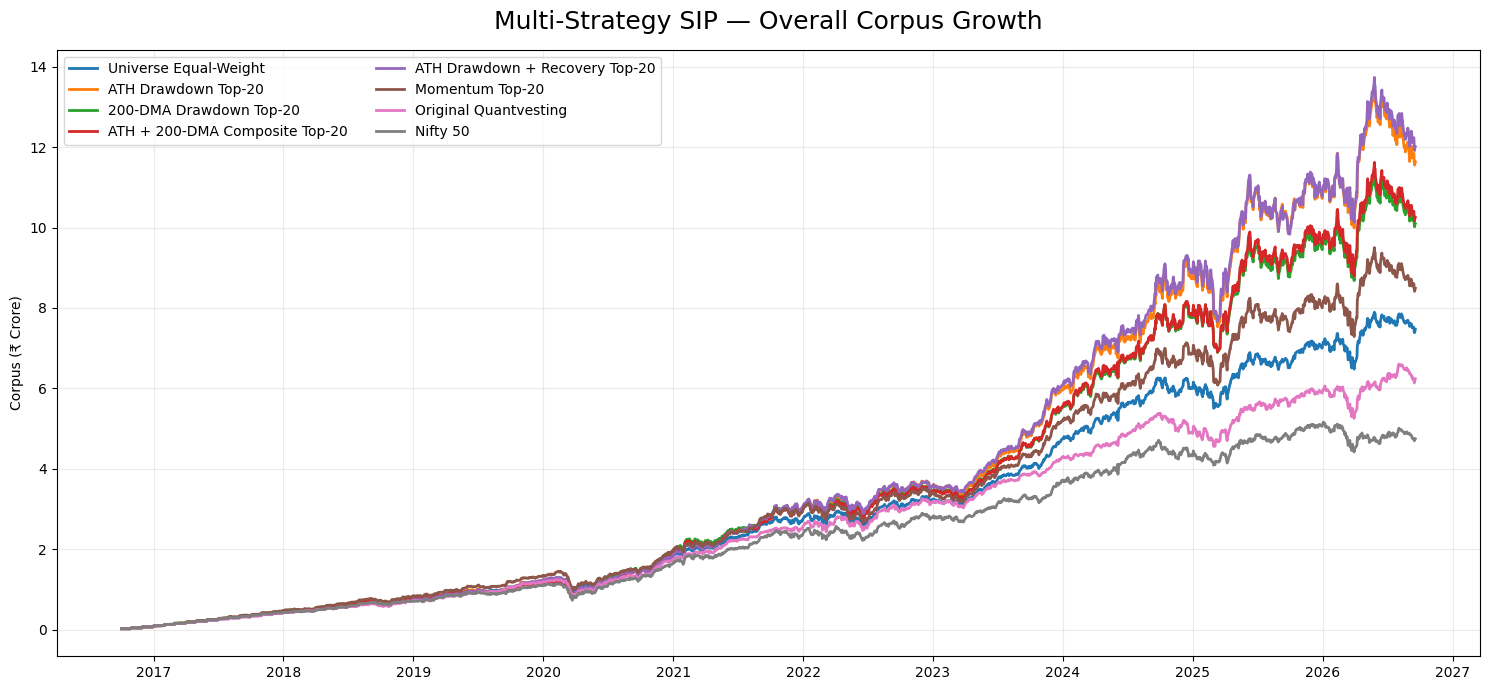

In [11]:
# 11. Overall corpus growth — same SIP contributions for every strategy
paths=pd.concat([v["portfolio"].set_index("date")["portfolio_value"].rename(k) for k,v in results.items()],axis=1).sort_index().ffill()
fig,ax=plt.subplots(figsize=(15,7))
for col in paths.columns: ax.plot(paths.index,paths[col]/1e7,label=col,linewidth=2)
ax.set_title("Multi-Strategy SIP — Overall Corpus Growth",fontsize=18,pad=15)
ax.set_ylabel("Corpus (₹ Crore)"); ax.grid(alpha=.25); ax.legend(ncol=2); plt.tight_layout(); plt.show()


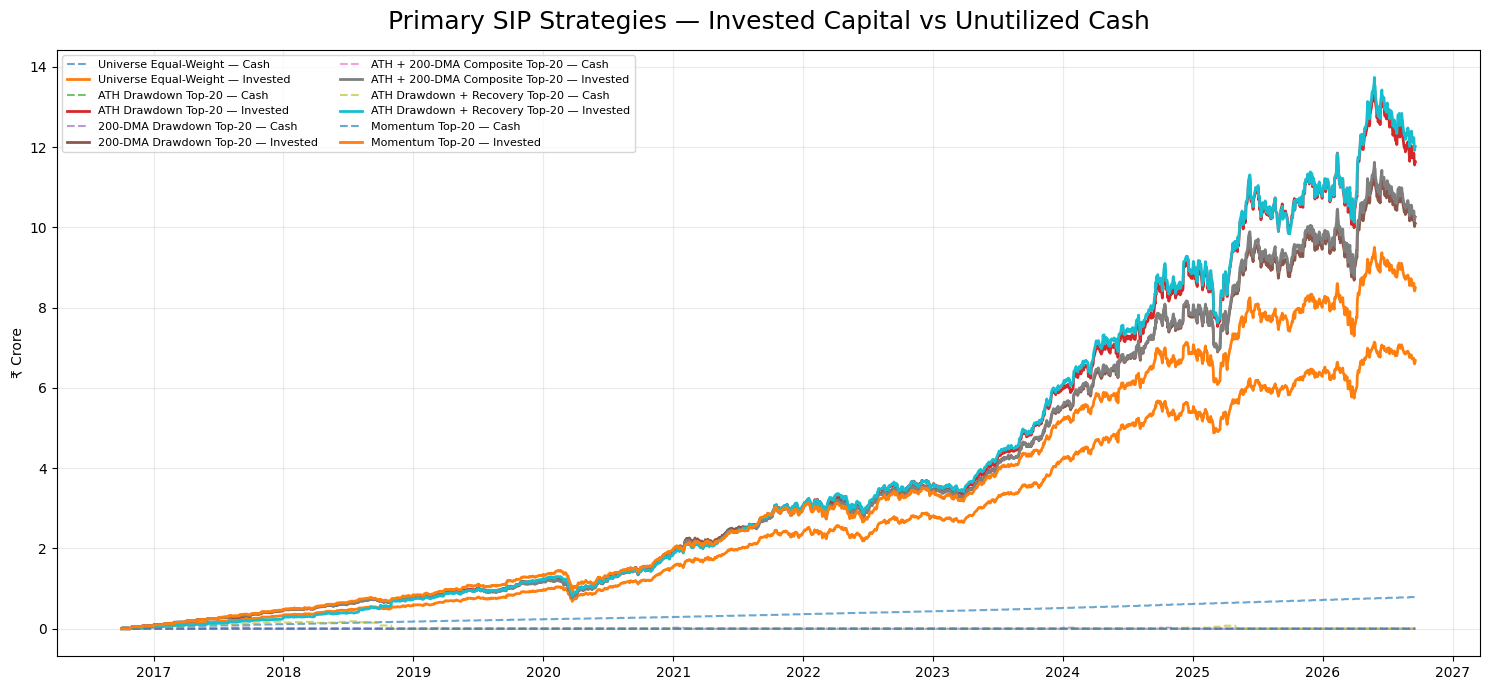

In [12]:
# 12. Invested value vs unutilized cash — primary strategies
fig,ax=plt.subplots(figsize=(15,7))
for name in PRIMARY_STRATEGIES:
    p=results[name]["portfolio"].set_index("date")
    ax.plot(p.index,p["cash"]/1e7,linestyle="--",alpha=.65,label=f"{name} — Cash")
    ax.plot(p.index,p["invested_value"]/1e7,linewidth=2,label=f"{name} — Invested")
ax.set_title("Primary SIP Strategies — Invested Capital vs Unutilized Cash",fontsize=18,pad=15)
ax.set_ylabel("₹ Crore"); ax.grid(alpha=.25); ax.legend(ncol=2,fontsize=8); plt.tight_layout(); plt.show()


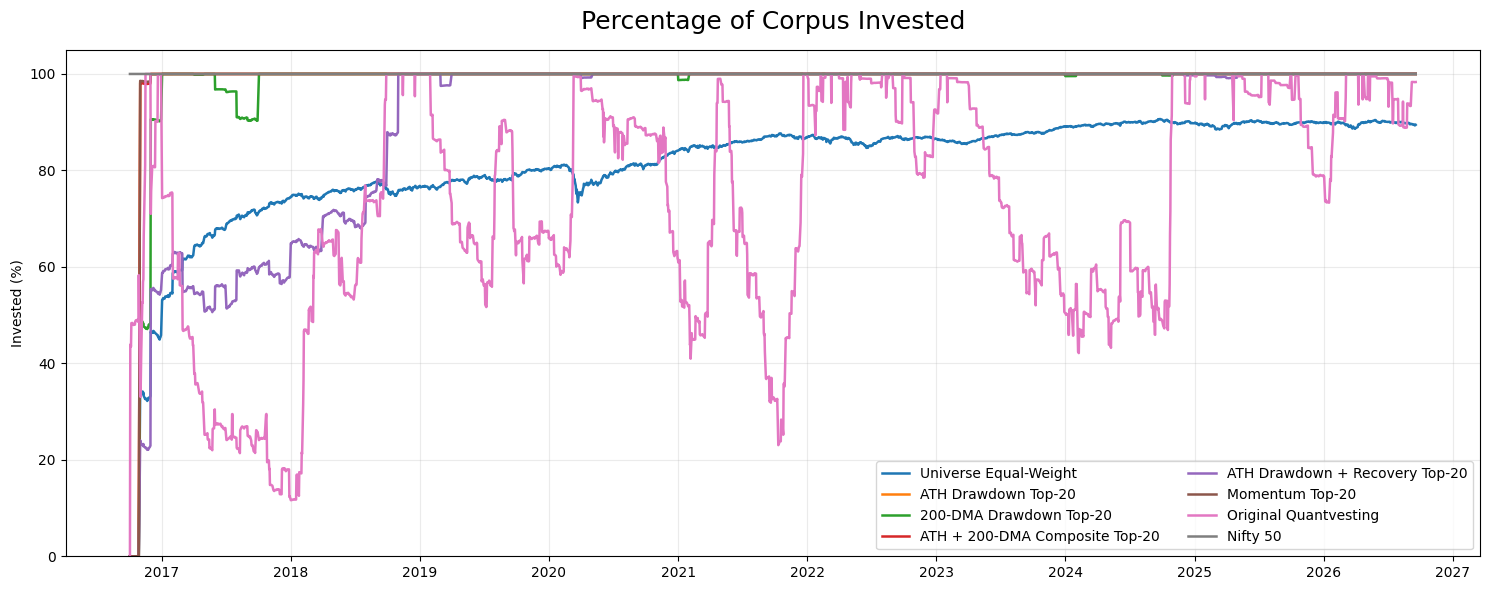

In [13]:
# 13. Invested percentage comparison
fig,ax=plt.subplots(figsize=(15,6))
for name,v in results.items():
    p=v["portfolio"].set_index("date")
    ax.plot(p.index,p["invested_pct"]*100,label=name,linewidth=1.8)
ax.set_title("Percentage of Corpus Invested",fontsize=18,pad=15)
ax.set_ylabel("Invested (%)"); ax.set_ylim(0,105); ax.grid(alpha=.25); ax.legend(ncol=2); plt.tight_layout(); plt.show()


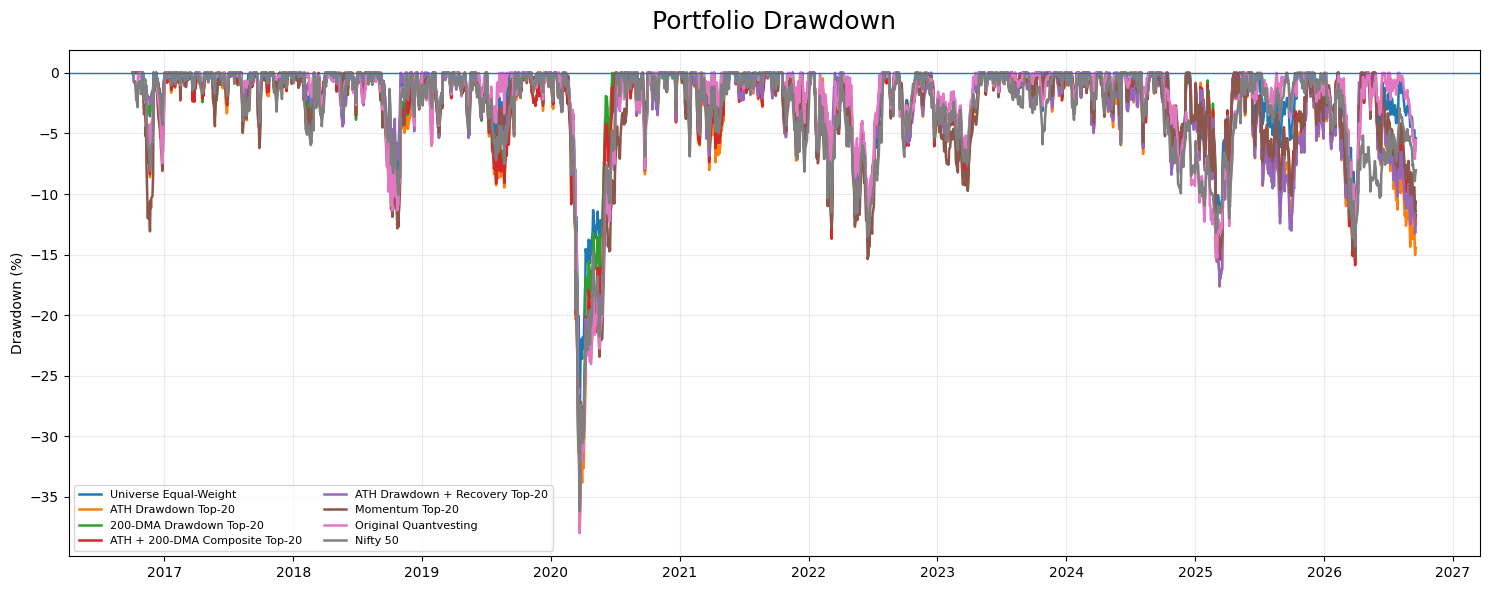

In [14]:
# 14. Drawdown comparison
fig,ax=plt.subplots(figsize=(15,6))
for name,v in results.items():
    p=v["portfolio"].set_index("date")
    ax.plot(p.index,p["drawdown"]*100,label=name,linewidth=1.8)
ax.axhline(0,linewidth=1)
ax.set_title("Portfolio Drawdown",fontsize=18,pad=15); ax.set_ylabel("Drawdown (%)"); ax.grid(alpha=.25); ax.legend(ncol=2,fontsize=8); plt.tight_layout(); plt.show()


In [15]:
# 15. Market-regime analysis
# Merge each strategy's daily portfolio with the Nifty diagnostic regime.
reg=regime_daily[["regime","drawdown","ret_6m"]].rename(columns={"drawdown":"nifty_drawdown","ret_6m":"nifty_6m_return"})
regime_tables={}
for name,v in results.items():
    p=v["portfolio"].copy().set_index("date")
    q=p.join(reg,how="inner")
    # Daily returns are used only for descriptive regime statistics.
    q["daily_return"]=q["portfolio_value"].pct_change()
    rows=[]
    for regime_name,g in q.groupby("regime"):
        if len(g)<5: continue
        start=float(g["portfolio_value"].iloc[0]); end=float(g["portfolio_value"].iloc[-1])
        rows.append({"Strategy":name,"Regime":regime_name,"Days":len(g),"Start Corpus":start,"End Corpus":end,
                     "Period Change":end/start-1 if start else np.nan,"Worst Drawdown":float(g["drawdown"].min()),
                     "Avg Invested %":float(g["invested_pct"].mean())})
    regime_tables[name]=pd.DataFrame(rows)

regime_summary=pd.concat(regime_tables.values(),ignore_index=True) if regime_tables else pd.DataFrame()
display(regime_summary.sort_values(["Regime","Strategy"]).style.format({"Start Corpus":"₹{:,.0f}","End Corpus":"₹{:,.0f}","Period Change":"{:.2%}","Worst Drawdown":"{:.2%}","Avg Invested %":"{:.1%}"}))

print("Regime definition used for diagnostics:")
print("• Stress / Bear: Nifty drawdown ≤ -10% and trailing 6-month return < 0")
print("• Recovery: Nifty drawdown ≤ -10% and trailing 6-month return ≥ 0")
print("• Expansion / Bull: drawdown > -3%, 6-month return > 0 and Nifty above 200-DMA")
print("• Transition / Sideways: remaining observations with sufficient history")


,Strategy,Regime,Days,Start Corpus,End Corpus,Period Change,Worst Drawdown,Avg Invested %
8,200-DMA Drawdown Top-20,Expansion / Bull,1074,"₹250,000","₹96,601,356",38540.54%,-6.13%,98.6%
12,ATH + 200-DMA Composite Top-20,Expansion / Bull,1074,"₹250,000","₹98,500,267",39300.11%,-6.03%,99.1%
16,ATH Drawdown + Recovery Top-20,Expansion / Bull,1074,"₹250,000","₹110,544,174",44117.67%,-7.00%,88.4%
4,ATH Drawdown Top-20,Expansion / Bull,1074,"₹250,000","₹110,229,488",43991.80%,-7.18%,99.1%
20,Momentum Top-20,Expansion / Bull,1074,"₹250,000","₹81,878,892",32651.56%,-5.32%,99.1%
28,Nifty 50,Expansion / Bull,1074,"₹251,698","₹50,648,851",20022.87%,-2.91%,100.0%
24,Original Quantvesting,Expansion / Bull,1074,"₹250,000","₹60,165,587",23966.23%,-2.49%,56.6%
0,Universe Equal-Weight,Expansion / Bull,1074,"₹250,000","₹71,695,398",28578.16%,-4.03%,81.2%
9,200-DMA Drawdown Top-20,Recovery,25,"₹479,484","₹100,839,686",20930.86%,-11.50%,91.6%
13,ATH + 200-DMA Composite Top-20,Recovery,25,"₹453,152","₹102,403,810",22498.12%,-11.87%,99.7%


Regime definition used for diagnostics:
• Stress / Bear: Nifty drawdown ≤ -10% and trailing 6-month return < 0
• Recovery: Nifty drawdown ≤ -10% and trailing 6-month return ≥ 0
• Expansion / Bull: drawdown > -3%, 6-month return > 0 and Nifty above 200-DMA
• Transition / Sideways: remaining observations with sufficient history


In [16]:
# 16. Calendar-year comparison — useful cross-check against regime labels
calendar_rows=[]
for name,v in results.items():
    p=v["portfolio"].copy(); p["year"]=p["date"].dt.year
    for year,g in p.groupby("year"):
        if len(g)<20: continue
        start=float(g["portfolio_value"].iloc[0]); end=float(g["portfolio_value"].iloc[-1])
        calendar_rows.append({"Strategy":name,"Year":year,"Start Corpus":start,"End Corpus":end,"Year Change":end/start-1 if start else np.nan,"Worst DD":float(g["drawdown"].min())})
calendar_df=pd.DataFrame(calendar_rows)
display(calendar_df.sort_values(["Year","Strategy"]).style.format({"Start Corpus":"₹{:,.0f}","End Corpus":"₹{:,.0f}","Year Change":"{:.2%}","Worst DD":"{:.2%}"}))


,Strategy,Year,Start Corpus,End Corpus,Year Change,Worst DD
22,200-DMA Drawdown Top-20,2016,"₹250,000","₹732,264",192.91%,-4.55%
33,ATH + 200-DMA Composite Top-20,2016,"₹250,000","₹716,758",186.70%,-8.36%
44,ATH Drawdown + Recovery Top-20,2016,"₹250,000","₹735,953",194.38%,-3.08%
11,ATH Drawdown Top-20,2016,"₹250,000","₹708,654",183.46%,-8.63%
55,Momentum Top-20,2016,"₹250,000","₹673,872",169.55%,-13.08%
77,Nifty 50,2016,"₹251,698","₹719,796",185.98%,-8.08%
66,Original Quantvesting,2016,"₹250,000","₹713,450",185.38%,-7.44%
0,Universe Equal-Weight,2016,"₹250,000","₹725,169",190.07%,-3.59%
23,200-DMA Drawdown Top-20,2017,"₹991,046","₹4,569,020",361.03%,-4.77%
34,ATH + 200-DMA Composite Top-20,2017,"₹976,178","₹4,460,556",356.94%,-4.49%


In [17]:
# 17. Monthly SIP diagnostics and concentration snapshots
monthly=pd.DataFrame({"date":sip_dates})
monthly["contribution"]=SIP_AMOUNT
for name,v in results.items():
    p=v["portfolio"].set_index("date")
    monthly[name+" Corpus"]=monthly["date"].map(lambda d: float(p.loc[d,"portfolio_value"]) if d in p.index else np.nan)
    monthly[name+" Cash"]=monthly["date"].map(lambda d: float(p.loc[d,"cash"]) if d in p.index else np.nan)
    monthly[name+" Invested %"]=monthly["date"].map(lambda d: float(p.loc[d,"invested_pct"]) if d in p.index else np.nan)

display(monthly.tail(12).style.format({c:"₹{:,.0f}" for c in monthly.columns if "Corpus" in c or c=="contribution" or "Cash" in c}).format({c:"{:.1%}" for c in monthly.columns if "Invested %" in c}).hide(axis="index"))


date,contribution,Universe Equal-Weight Corpus,Universe Equal-Weight Cash,Universe Equal-Weight Invested %,ATH Drawdown Top-20 Corpus,ATH Drawdown Top-20 Cash,ATH Drawdown Top-20 Invested %,200-DMA Drawdown Top-20 Corpus,200-DMA Drawdown Top-20 Cash,200-DMA Drawdown Top-20 Invested %,ATH + 200-DMA Composite Top-20 Corpus,ATH + 200-DMA Composite Top-20 Cash,ATH + 200-DMA Composite Top-20 Invested %,ATH Drawdown + Recovery Top-20 Corpus,ATH Drawdown + Recovery Top-20 Cash,ATH Drawdown + Recovery Top-20 Invested %,Momentum Top-20 Corpus,Momentum Top-20 Cash,Momentum Top-20 Invested %,Original Quantvesting Corpus,Original Quantvesting Cash,Original Quantvesting Invested %,Nifty 50 Corpus,Nifty 50 Cash,Nifty 50 Invested %
2025-10-01 00:00:00,250000,65836626.466220,6945371.391727,89.5%,100383083.651840,149.826859,100.0%,88877305.696212,216.275374,100.0%,90483537.003997,147.836608,100.0%,99654097.707530,176.821086,100.0%,74984958.030428,73.614076,100.0%,56381071.037323,1158.030578,100.0%,47958282.077350,0.000000,100.0%
2025-11-03 00:00:00,250000,69779424.313900,7033429.972164,89.9%,106966981.044763,133.239038,100.0%,94027505.361320,199.687553,100.0%,95539625.549263,131.248787,100.0%,107684409.015707,296.237021,100.0%,79666114.618285,117.677123,100.0%,58759405.398037,6366810.723599,89.2%,49998661.852957,0.000000,100.0%
2025-12-01 00:00:00,250000,71782404.422740,7117771.975108,90.1%,113038977.544865,253.856785,100.0%,98719776.453403,320.305301,100.0%,100309750.533039,251.866535,100.0%,113415076.137335,60.220373,100.0%,83335889.900626,302.485221,100.0%,59950377.686616,12450512.267274,79.2%,51047205.588956,-0.000000,100.0%
2026-01-01 00:00:00,250000,71027089.302566,7203076.519485,89.9%,108661636.531264,167.710616,100.0%,95944621.234632,234.159132,100.0%,97276132.166258,165.720366,100.0%,109202220.293686,250.498703,100.0%,81270359.673586,17.091585,100.0%,59606005.948731,12700512.267274,78.7%,51239632.411702,-0.000000,100.0%
2026-02-02 00:00:00,250000,69583374.208768,7286537.001523,89.5%,107565890.293261,23.936663,100.0%,94239122.283960,23.234552,100.0%,95502367.430452,21.946413,100.0%,107898810.812443,735.662632,100.0%,79603734.389627,10.218515,100.0%,58094663.234884,5178890.820608,91.1%,49418529.493389,0.000000,100.0%
2026-03-02 00:00:00,250000,70494469.716922,7369849.061313,89.5%,107370356.983746,123.522900,100.0%,94173186.039936,122.820789,100.0%,95764448.564022,121.532650,100.0%,108005562.809964,82.621244,100.0%,79593777.778683,81.161862,100.0%,58952964.285325,5791948.586748,90.2%,49231573.386404,-0.000000,100.0%
2026-04-01 00:00:00,250000,66591956.245529,7452758.668380,88.8%,104849739.757940,199.073125,100.0%,90460745.526593,198.371014,100.0%,91886148.234853,197.082875,100.0%,105891794.449321,733.032756,100.0%,75969530.284189,731.573374,100.0%,53908011.271218,118.403359,100.0%,45150154.039182,0.000000,100.0%
2026-05-01 00:00:00,250000,74781759.662201,7535531.990723,89.9%,123003974.977424,151.397651,100.0%,104421329.783918,150.695539,100.0%,106375190.026480,149.407400,100.0%,124712153.203125,185.743866,100.0%,87924579.402993,339.133858,100.0%,60174956.498985,3140749.241875,94.8%,nan,nan,nan%
2026-06-01 00:00:00,250000,76702558.593333,7615800.640330,90.1%,129258493.904399,136.812831,100.0%,108830192.749893,4.323288,100.0%,110926761.081276,3.035148,100.0%,130677587.242524,86.423204,100.0%,90985521.405667,672.570462,100.0%,60273957.238449,555532.777970,99.1%,46796839.237853,-0.000000,100.0%
2026-07-01 00:00:00,250000,77526652.219393,7698376.796938,90.1%,129370845.981859,191.331545,100.0%,109255902.096487,141.966544,100.0%,111632091.067000,140.678404,100.0%,130985560.239243,291.166993,100.0%,91836968.286387,454.681040,100.0%,62798006.268692,805532.777970,98.7%,48294938.228137,-0.000000,100.0%


In [18]:
# 18. Concentration analysis from trade ledgers
# This is based on marked-to-market positions reconstructed from executed buys.
def concentration_snapshot(trades, portfolio, name):
    if trades.empty or "symbol" not in trades.columns:
        return pd.DataFrame()
    buys=trades[trades["event"].astype(str).str.contains("BUY|ENTRY",regex=True)].copy()
    if buys.empty:return pd.DataFrame()
    # Approximate cumulative invested cost by symbol; useful as a contribution/concentration diagnostic.
    by=buys.groupby("symbol")["notional"].sum().sort_values(ascending=False)
    total=by.sum()
    top5=by.head(5).sum()/total if total else np.nan
    top10=by.head(10).sum()/total if total else np.nan
    return pd.DataFrame([{"Strategy":name,"Top-5 share of cumulative purchases":top5,"Top-10 share of cumulative purchases":top10,"Distinct purchased stocks":by.size}])

conc=pd.concat([concentration_snapshot(v["trades"],v["portfolio"],name) for name,v in results.items() if name!="Nifty 50"],ignore_index=True)
display(conc.style.format({"Top-5 share of cumulative purchases":"{:.1%}","Top-10 share of cumulative purchases":"{:.1%}"}))


,Strategy,Top-5 share of cumulative purchases,Top-10 share of cumulative purchases,Distinct purchased stocks
0,Universe Equal-Weight,12.4%,24.6%,51
1,ATH Drawdown Top-20,47.1%,68.4%,43
2,200-DMA Drawdown Top-20,32.1%,50.1%,47
3,ATH + 200-DMA Composite Top-20,36.6%,58.0%,45
4,ATH Drawdown + Recovery Top-20,36.7%,56.7%,47
5,Momentum Top-20,30.0%,53.6%,45
6,Original Quantvesting,23.6%,38.7%,52


## 4. Audit and implementation checks

The audit below is deliberately strict. It checks that:

- every primary strategy received the same number and amount of SIP contributions;
- no primary purchase took the resulting position above 5% of the corpus used for that month's sizing decision;
- primary strategies never sell;
- cash never becomes negative;
- cash + marked-to-market invested value equals portfolio corpus;
- the original Quantvesting reference also respects the new 5% entry cap;
- the comparison uses the same historical dates and SIP schedule.

The audit does **not** prove that the strategy is economically sound; it only checks that the backtest implemented the stated rules.


In [19]:
# 19. Backtest audit

audit=[]
for name in PRIMARY_STRATEGIES:
    v=results[name]; p=v["portfolio"]; t=v["trades"]
    buys=t[t["event"].astype(str).str.contains("BUY",regex=True)] if not t.empty else pd.DataFrame()
    audit.append({"Strategy":name,"60 SIPs":len(v["contributions"])==len(sip_dates),"Capital = ₹1.50 Cr":abs(v["contributions"]["contribution"].sum()-SIP_AMOUNT*len(sip_dates))<1e-6,
                  "5% cap passed":bool((buys["position_pct_after"]<=MAX_POSITION_PCT+1e-10).all()) if not buys.empty else True,
                  "No sells":bool(not t["event"].astype(str).str.contains("SELL|EXIT",regex=True).any()) if not t.empty else True,
                  "Cash non-negative":bool((p["cash"]>=-1e-7).all()),
                  "Accounting identity":bool(np.allclose(p["cash"]+p["invested_value"],p["portfolio_value"],rtol=0,atol=1e-6))})

qbuys=qref_t[qref_t["event"]=="ENTRY"] if not qref_t.empty else pd.DataFrame()
audit.append({"Strategy":"Original Quantvesting","60 SIPs":len(qref_c)==len(sip_dates),"Capital = ₹1.50 Cr":abs(qref_c["contribution"].sum()-SIP_AMOUNT*len(sip_dates))<1e-6,
              "5% cap passed":bool((qbuys["position_pct_after"]<=MAX_POSITION_PCT+1e-10).all()) if not qbuys.empty else True,
              "No sells":False,"Cash non-negative":bool((qref_p["cash"]>=-1e-7).all()),
              "Accounting identity":bool(np.allclose(qref_p["cash"]+qref_p["invested_value"],qref_p["portfolio_value"],rtol=0,atol=1e-6))})

audit_df=pd.DataFrame(audit)
display(audit_df.style.hide(axis="index"))


Strategy,60 SIPs,Capital = ₹1.50 Cr,5% cap passed,No sells,Cash non-negative,Accounting identity
Universe Equal-Weight,True,True,True,True,True,True
ATH Drawdown Top-20,True,True,True,True,True,True
200-DMA Drawdown Top-20,True,True,True,True,True,True
ATH + 200-DMA Composite Top-20,True,True,True,True,True,True
ATH Drawdown + Recovery Top-20,True,True,True,True,True,True
Momentum Top-20,True,True,True,True,True,True
Original Quantvesting,True,True,True,False,True,True


In [20]:
# 20. Final dashboard — descriptive comparison, not a single-score ranking
headline=metrics[["Ending Corpus","Profit","XIRR","Max Drawdown","Average Invested %","Average Cash %","Final Cash","Deployment %","Final Holdings", "Contributed Capital"]].copy()
headline["Profit % of Contributions"]=headline["Profit"]/headline["Contributed Capital"]

display(headline.sort_values("Ending Corpus",ascending=False).style.format({
    "Ending Corpus":"₹{:,.0f}","Profit":"₹{:,.0f}","XIRR":"{:.2%}","Max Drawdown":"{:.2%}",
    "Average Invested %":"{:.1%}","Average Cash %":"{:.1%}","Final Cash":"₹{:,.0f}","Deployment %":"{:.1f}%",
    "Profit % of Contributions":"{:.1%}","Final Holdings":"{:,.0f}"
}))

print("\nPrimary strategies:")
print("  • Universe Equal-Weight")
print("  • ATH Drawdown Top-20")
print("  • 200-DMA Drawdown Top-20")
print("  • ATH + 200-DMA Composite Top-20")
print("  • ATH Drawdown + Recovery Top-20")
print("  • Momentum Top-20")
print("\nUse the regime table, drawdowns, deployment %, cash drag and concentration together with XIRR/ending corpus. A single 60-month outcome is not sufficient evidence of robustness.")

,Ending Corpus,Profit,XIRR,Max Drawdown,Average Invested %,Average Cash %,Final Cash,Deployment %,Final Holdings,Contributed Capital,Profit % of Contributions
ATH Drawdown + Recovery Top-20,"₹120,150,011","₹90,150,011",26.33%,-36.65%,91.5%,8.5%,₹221,99.9%,47,30000000.000000,300.5%
ATH Drawdown Top-20,"₹116,352,007","₹86,352,007",25.73%,-37.81%,99.3%,0.7%,₹43,99.9%,43,30000000.000000,287.8%
ATH + 200-DMA Composite Top-20,"₹102,560,883","₹72,560,883",23.39%,-36.80%,99.3%,0.7%,₹173,99.9%,45,30000000.000000,241.9%
200-DMA Drawdown Top-20,"₹100,960,842","₹70,960,842",23.09%,-34.92%,98.5%,1.5%,₹203,99.9%,47,30000000.000000,236.5%
Momentum Top-20,"₹84,915,931","₹54,915,931",19.87%,-35.49%,99.3%,0.7%,₹131,99.9%,45,30000000.000000,183.1%
Universe Equal-Weight,"₹74,676,007","₹44,676,007",17.48%,-28.06%,81.5%,18.5%,"₹7,880,537",73.7%,51,30000000.000000,148.9%
Original Quantvesting,"₹62,398,820","₹32,398,820",14.12%,-38.00%,73.5%,26.5%,"₹1,045,491",836.1%,35,30000000.000000,108.0%
Nifty 50,"₹47,447,472","₹18,197,472",9.45%,-36.17%,100.0%,-0.0%,₹0,99.9%,1,29250000.000000,62.2%



Primary strategies:
  • Universe Equal-Weight
  • ATH Drawdown Top-20
  • 200-DMA Drawdown Top-20
  • ATH + 200-DMA Composite Top-20
  • ATH Drawdown + Recovery Top-20
  • Momentum Top-20

Use the regime table, drawdowns, deployment %, cash drag and concentration together with XIRR/ending corpus. A single 60-month outcome is not sufficient evidence of robustness.
